# 28 — `quadtree`

`Map.quadtree` bins points into **adaptive** square cells: a cell keeps splitting in four while it holds more
than `nmax` points, so dense areas end with small cells and empty areas stay coarse. Where `voronoi` gives one
cell per point, a quadtree gives one cell per *neighbourhood* — the tool for aggregate values at a readable cell
count.

By the end you will be able to build a quadtree choropleth, control how finely it splits, and change the
statistic each cell reports.

API: [`Map.quadtree`](../../reference/static_map.md).

> **Where this data comes from.** Everything in this notebook is real, downloaded with
> [earthlens](https://github.com/serapeum-org/earthlens) and committed under `examples/data/`.
> `examples/data/ATTRIBUTION.md` records each source and its licence.


**Setup**.

In [1]:
%matplotlib inline
from pathlib import Path

import matplotlib.pyplot as plt
from pyramids.feature import FeatureCollection

from digitalearth.static import Map

# The notebook's own folder is the kernel's working directory, so the bundled
# example data sits three levels up: docs/examples/plots -> repo root.
DATA = Path("../../../examples/data")

# UTM zone 32N: a metric CRS, correct for south-west Germany. Distance-based
# renders (Voronoi, hex lattices, kernels) must not be computed in degrees.
UTM32 = 25832


## The data

The 3,000 GBIF bird records for 2023 — here used raw, one point per observation.

In [2]:
birds = FeatureCollection.read_file(str(DATA / "heidelberg_birds_2023.geojson"))
print(f"{len(birds)} bird records, {birds['species'].nunique()} species, EPSG:{birds.crs.to_epsg()}")
birds[["species", "eventDate", "uncertainty_m"]].head()

3000 bird records, 111 species, EPSG:4326


,species,eventDate,uncertainty_m
0,Corvus corone,2023-01-11 12:27:25+00:00,NaN
1,Cyanistes caeruleus,2023-01-11 15:49:00+00:00,8.0
2,Phalacrocorax carbo,2023-01-11 11:58:48+00:00,NaN
3,Cyanistes caeruleus,2023-01-11 15:49:04+00:00,8.0
4,Alopochen aegyptiaca,2023-01-11 11:56:46+00:00,NaN


`uncertainty_m` is the recorded coordinate uncertainty in metres. It is present on about a third of the records,
which is normal for GBIF, and it is the numeric column we aggregate below.

## Quickstart — density-shaped cells

`nmax` shapes the tree: a cell splits while it holds more than `nmax` points. With 3,000 records, `nmax=60`
subdivides down to roughly fifty cells.

C:\gdrive\algorithms\serapeum-github-org\repos\visualization\Digital-Earth\src\digitalearth\static\maps\vector.py:1325: RuntimeWarning: Mean of empty slice
  return lambda idx: float(reducer(col_vals[idx]))


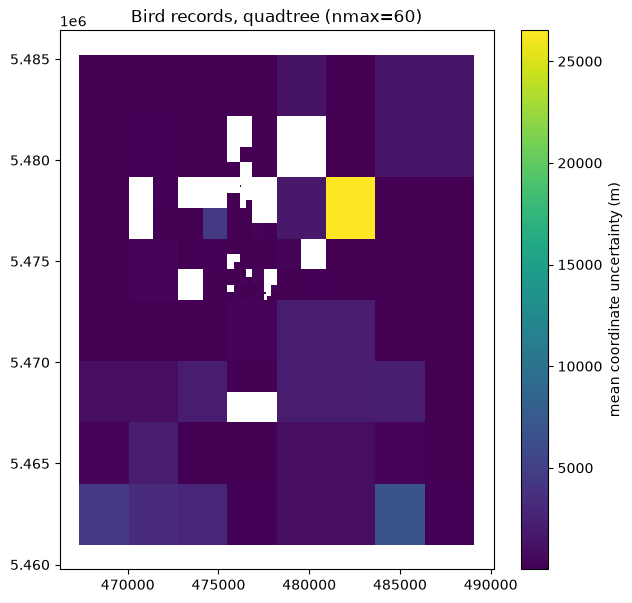

In [3]:
m = Map(crs=UTM32, figsize=(7, 7))
m.quadtree(birds, column="uncertainty_m", nmax=60, cmap="viridis")
m.colorbar(label="mean coordinate uncertainty (m)")
m.set_title("Bird records, quadtree (nmax=60)")
m.fig;

Two signals in one figure. The cell **sizes** are recording density: the small cells are the heavily-watched city
and river. The **colours** are mean coordinate uncertainty, and the pattern is interesting — the tight urban
cells are also the precise ones, because city records are pinned to a path or a garden, while the coarse outlying
cells carry records placed to the nearest village.

## How `nmax` changes the picture

`nmax` trades resolution against noise. Small `nmax` splits aggressively — more cells, each averaging fewer
records, so each is noisier. Large `nmax` gives a coarse but stable map.

C:\gdrive\algorithms\serapeum-github-org\repos\visualization\Digital-Earth\src\digitalearth\static\maps\vector.py:1325: RuntimeWarning: Mean of empty slice
  return lambda idx: float(reducer(col_vals[idx]))
C:\gdrive\algorithms\serapeum-github-org\repos\visualization\Digital-Earth\src\digitalearth\static\maps\vector.py:1325: RuntimeWarning: Mean of empty slice
  return lambda idx: float(reducer(col_vals[idx]))
C:\gdrive\algorithms\serapeum-github-org\repos\visualization\Digital-Earth\src\digitalearth\static\maps\vector.py:1325: RuntimeWarning: Mean of empty slice
  return lambda idx: float(reducer(col_vals[idx]))


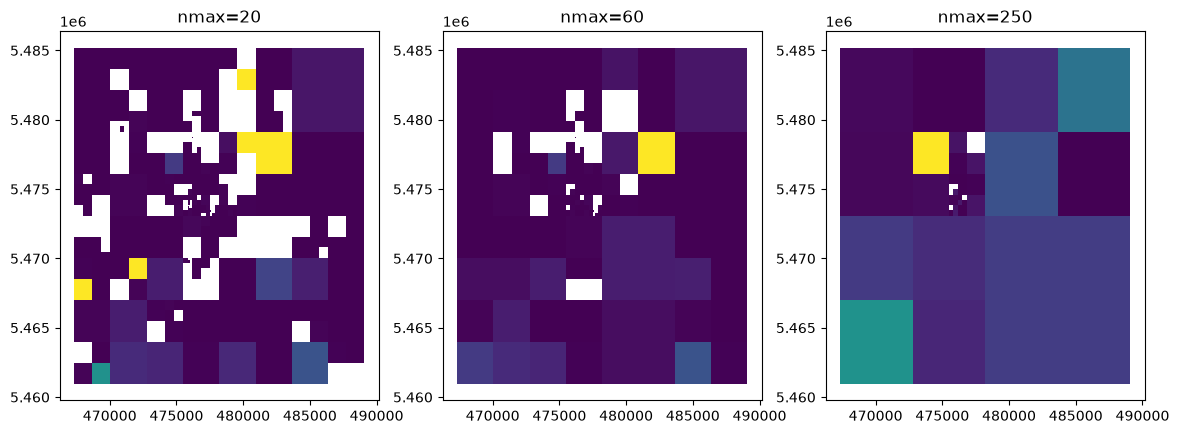

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.8))
for ax, nmax in zip(axes, (20, 60, 250)):
    panel = Map(ax=ax, crs=UTM32)
    panel.quadtree(birds, column="uncertainty_m", nmax=nmax, cmap="viridis")
    ax.set_title(f"nmax={nmax}")
fig;

Left to right: fine detail on thin evidence, a readable compromise, and a handful of cells that average the
city away. Neither extreme is "right" — pick `nmax` for how much averaging you will accept, and say which you
used.

## Changing the statistic with `agg`

Each cell reports the **mean** of `column` by default. `agg` takes the usual reducers, so the same geometry can
answer a different question.

| argument | meaning | typical value |
|---|---|---|
| `column` | attribute to aggregate | a numeric column name |
| `agg` | statistic per cell | `"mean"` (default), `"max"`, `"min"`, `"count"`, `"sum"` |
| `nmax` | split while a cell holds more than this many points | `100` (default); smaller = finer |
| `nmin` | stop splitting below this many points | `0` |
| `clip` | polygons to trim the cells to | a polygon `FeatureCollection` |

C:\gdrive\algorithms\serapeum-github-org\repos\visualization\Digital-Earth\src\digitalearth\static\maps\vector.py:1325: RuntimeWarning: All-NaN slice encountered
  return lambda idx: float(reducer(col_vals[idx]))


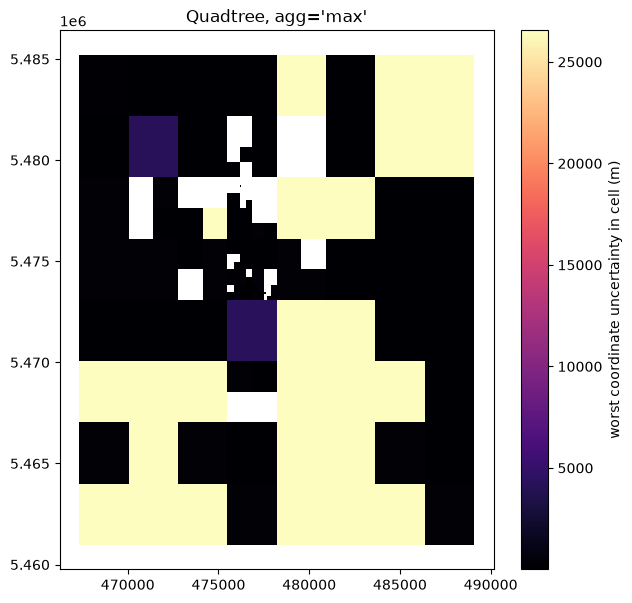

In [5]:
m = Map(crs=UTM32, figsize=(7, 7))
m.quadtree(birds, column="uncertainty_m", agg="max", nmax=60, cmap="magma")
m.colorbar(label="worst coordinate uncertainty in cell (m)")
m.set_title("Quadtree, agg='max'")
m.fig;

`max` changes the question from "how precise is this area typically?" to "what is the vaguest record in it?" —
which is the one to use when deciding whether a cell's records can be trusted at all. A single 10 km-uncertainty
record now lights up its whole cell, and that is the point.

## Takeaway

- A quadtree's **cell size is the density signal**; its colour is the aggregated value.
- `nmax` is the main control: smaller splits further, buying detail with noise.
- `agg` picks the statistic — `mean` for the typical case, `max` for the worst case.
- Prefer `quadtree` over `voronoi` when you want neighbourhood aggregates rather than per-site cells.

Next: [`29_hexbin`](29_hexbin.ipynb) uses a fixed lattice instead of an adaptive one.